In [18]:
import pandas as pd
import matplotlib.pyplot as plt

import torch 
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader
import torchvision
from torchvision import datasets, transforms, models
from torchvision.utils import make_grid

from dataset_subset import make_cifar10_demo_subsets


In [19]:
SEED = 42
torch.manual_seed(SEED)

In [20]:
CIFAR10_CLASSES = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck",
]

CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD = (0.2470, 0.2435, 0.2616)

In [21]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])


train_dataset = datasets.CIFAR10(
    root='data/',
    download=True,
    train=True,
    transform=transform
)

test_dataset = datasets.CIFAR10(
    root='data/',
    download=True,
    train=False,
    transform=transform
)

print(len(train_dataset))
print(len(test_dataset))

50000
10000


In [22]:
USE_SMALL_SUBSET = False

if USE_SMALL_SUBSET:
    train_dataset, test_dataset = make_cifar10_demo_subsets(train_dataset, test_dataset, seed=SEED)
    
    
train_dataloader = DataLoader(
    dataset=train_dataset,
    shuffle=True,
    batch_size=64
)

test_dataloader = DataLoader(
    dataset=test_dataset,
    shuffle=False,
    batch_size=64
)

In [23]:
images, labels = next(iter(test_dataloader))
print("images shape: ", images.shape)
print("labels shape: ", labels.shape)
print("first 10 labels: ", [CIFAR10_CLASSES[i] for i in labels[:10]])

images shape:  torch.Size([64, 3, 32, 32])
labels shape:  torch.Size([64])
first 10 labels:  ['cat', 'ship', 'ship', 'airplane', 'frog', 'frog', 'automobile', 'frog', 'cat', 'automobile']


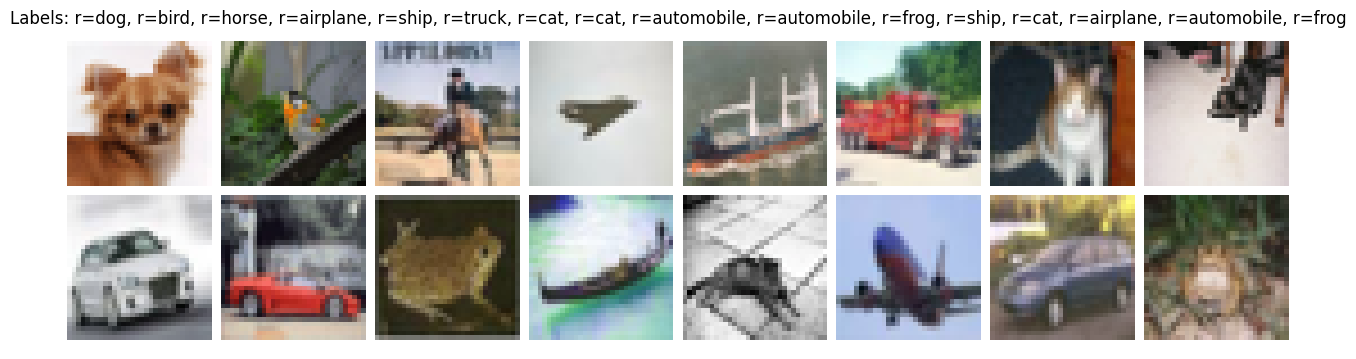

In [16]:
def denormalize_images(images, mean=CIFAR10_MEAN, std=CIFAR10_STD):
    # mean, std.shape (3, ) 
    mean = torch.tensor(mean).view(1, 3, 1, 1)
    std = torch.tensor(std).view(1, 3, 1, 1)
    return torch.clamp(images.cpu() * std + mean, 0, 1)


def show_cifar10_sample(images, labels, n=16):
    grid = make_grid(denormalize_images(images[:n]), nrow=8, normalize=True, pad_value=1)
    
    plt.figure(figsize=(16, 6))
    plt.imshow(grid.permute(1, 2, 0))
    
    str_labels = [CIFAR10_CLASSES[i] for i in labels[:n]]
    
    title = ", ".join([f"r={n}" for n in str_labels])
    
    plt.title("Labels: " + title)
    plt.axis("off")
    
    plt.show()
    
    
show_cifar10_sample(images, labels, 16)

In [17]:
cifar_model = nn.Sequential(
    nn.Conv2d(3, 32, kernel_size=5, padding=2),
    nn.BatchNorm2d(32),
    nn.ReLU(),
    nn.MaxPool2d(2),
    
    nn.Conv2d(32, 64, kernel_size=5, padding=2),
    nn.BatchNorm2d(64),
    nn.ReLU(),
    nn.MaxPool2d(2),
    
    nn.Flatten(),
    nn.Linear(64 * 8 * 8, 128),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(128, 10)
)